__Delete this cell later__:

---

Things that needs check/changes:
- Idk if this requirements.txt is correct, if it is I thing its a good idea, this could also be done in a gitworkflow file, but maybe too much for now. 
- Check if source(s) and quotes are correct
- In the cleaning data section, idk about this price outlier removal - I just said everything under 500 remove. 


- Tackling overfitting, needs text
- Hyperparameters for grid search, the 5th parameters need a reason for refit='neg_rmse'.
- experiment with cv in grid search, maybe 5 is too much

- Check text under: "The reason for the selected models is as follows" and "We are going to be using the following error metrics to evalaute the models"

install the required packages for the project:
<br>
pip install -r requirements.txt

if the imports have changed:
<br>
pip freeze > requirements.txt

---

## Imports need for notebook 

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import pickle

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

## 1. Bussiness case / Problem statement

Across the world, cars are one of the most essential mode of transportaion. In som regions more then others, which leads to a high volume of vehicle transations. For example, according to S&P Global: <br><br>
&emsp;&emsp;*"[...] 2025 US auto sales in April expected to reach 1.49 million units [...]"*<br>
&emsp;&emsp;source: [automotive-insights](https://www.spglobal.com/automotive-insights/en/blogs/2025/02/us-auto-sales-2025) (last visited: 29-04-2025). 
<br>

Where there is a high number of cars being bought and sold, they will eventually end up at used car dealerships. According to [ibisworld](https://www.ibisworld.com/united-states/number-of-businesses/used-car-dealers/1004/) (last visited: 29-04-2025): There where <br>

&emsp;&emsp;*"[...] 130,152 Used Car Dealers in the US businesses as of 2023, an decrease of -0.6% from 2022."*
<br>

Based on this we can wonder how can these used car dealerships price their cars?
What factors inpacts the pricing of a used car? And can machine learning be used to give a accurate price prediction?

## 2. Data selection and preparation:

This section will include:
- Loading the data
- Cleaning the data

This exam project is based on the dataset: [Car Prices Dataset](https://www.kaggle.com/datasets/sidharth178/car-prices-dataset?select=train.csv) from kaggle. 

### 2.1 Load data

In [2]:
base_path = '../data/'

df = pd.read_csv(f'{base_path}dataset.csv', sep=',', header=0)

In [3]:
df.sample(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
16496,45816317,21639,-,CADILLAC,DTS,2008,Sedan,Yes,Petrol,4.6,161000 km,8.0,Automatic,Front,04-May,Left wheel,White,10
3414,45771518,12544,447,HONDA,Insight,2013,Hatchback,No,Hybrid,1.3,175930 km,4.0,Automatic,Front,04-May,Left wheel,Silver,0
17433,45782293,9095,-,VOLKSWAGEN,Golf GOLF 5,2005,Hatchback,Yes,Petrol,1.6,144000 km,4.0,Tiptronic,Front,04-May,Right-hand drive,Black,10
14847,45764647,18503,781,TOYOTA,Camry,2012,Sedan,Yes,Petrol,2.5,150000 km,4.0,Tiptronic,Front,04-May,Left wheel,Black,12
8635,45808924,15464,530,CHEVROLET,Aveo,2013,Hatchback,Yes,Petrol,1.6,134372 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4


In [4]:
df.shape

(19237, 18)

In [5]:
# Set float format to 2 decimal places, to avoid exponential notation
pd.set_option('display.float_format', '{:.2f}'.format)

df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,19237.00,19237.00,19237.00,19237.00,19237.00
mean,45576535.89,18555.93,2010.91,4.58,6.58
std,936591.42,190581.27,5.67,1.20,4.32
min,20746880.00,1.00,1939.00,1.00,0.00
25%,45698374.00,5331.00,2009.00,4.00,4.00
50%,45772308.00,13172.00,2012.00,4.00,6.00
75%,45802036.00,22075.00,2015.00,4.00,12.00
max,45816654.00,26307500.00,2020.00,16.00,16.00


__Explanation:__

We have loaded the data using pandas `read_csv` function, where we have specified the separator to separate by sep = ',' and with header = 0 to instruct that the first row of the csv file is a header, wich will become the columns in the dataframe.

After the data has been loaded, we verify that the data has been loadded properly by sampling 5 ranomd rows of the data, by using the `.sample` function: 

We use the command `.shape` to comefirm that is the right size of that we expect, as there have been sated on kaggle (rows: 19237, cols: 18).


We can see that the data has been loaded properly.
<br>
Additionally this process also helps us to quickly get a view and idea of the data we are going to work with. 
<br>
We can first of all see that the `ID` column is not need beacuse the datafram has its own bulid in index. 
<br>
Secondly we can see that the `Doors` column looks a bit strange, beacause it containes 3 opstions: '04-May', '02-Mar' or '>5', which couold be a mistake in the data, so this has to be checked more in detail. 
<br>
Thirdly we can see that when `Levy` don't have a value its just a '-'. 
<br>
Lastly we can also see that the `Price` has an unrealistic min value of 1.00 and a bit outlier of 26307500.00 as max value, more then likely this should just be removed.

### 2.2 Cleaning- and Preprocessing Data

##### 2.2.1 NaN values

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

__Explanation:__

By using the `.info()` function, we can see that there are no null values in the data; however when we load the data in, we could see that for column: `Levy`, had '-' instead of NaN. Additionally when using the `.info()` function, we can also see that the dtypes appear to be all most only objects, these should be converted before to right type at the end for this cleaning process at least.

---

##### 2.2.2 Levy column

In [7]:
df_dash_count = df['Levy'].where(df['Levy'] == '-').count()

print(f"Number of '-' in Levy in train set: {df_dash_count}")

Number of '-' in Levy in train set: 5819


In [8]:
levy_avg = np.sum(df['Levy'].where(df['Levy'] != '-').astype(float) / df.shape[0])

print(f"Average Levy in train set: {levy_avg}")

df['Levy'] = df['Levy'].replace('-', int(levy_avg))

Average Levy in train set: 632.5286687113374


__Explanation:__

We have exchanged the '-' with the average ´Levy´ value, which is 632 approximately.

---

##### 2.2.3 Price column

In [9]:
low_outliers_custom = df[df['Price'] < 500]
high_outliers_custom = df[df['Price'] > 500000]

high_outliers_custom

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
1225,45795524,627220,632,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3 Turbo,0 km,8.00,Tiptronic,4x4,04-May,Left wheel,Black,12
8541,45761204,872946,2067,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4,2531 km,8.00,Tiptronic,4x4,04-May,Left wheel,Black,0
16983,45812886,26307500,632,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999 km,4.00,Manual,Front,02-Mar,Left wheel,Blue,0


In [10]:
df = df[df['Price'] > 500]
df = df.drop(index=16983)

__Explanation:__

As we saw, when we used the descpribe function, the `Price` had an unrealistic min (1) and max (2.6 m) value, most likely outliers, even though max could be real. We will have a closer look at this.

We have come to that conclusion that the 2.6m car is more a mistake then the real price, and that cars under 500 should be removed.

---

##### 2.2.4 Doors column

In [11]:
df['Doors'].value_counts()

Doors
04-May    16695
02-Mar      757
>5          119
Name: count, dtype: int64

In [12]:
df['Doors'] = df['Doors'].replace({
    '04-May': '4',
    '02-Mar': '2',
    '>5': '5'
})

__Explanation:__

As we mentioned before in 2.1 load data, we observed that `Doors` had a wrong format, by mistake. We have used .value_counts() to get a full view over the different types of values present in the dataframe, so we can transform these into more usable values.

---

##### 2.2.5 Engine volume column

In [13]:
df['Engine volume'].value_counts()

Engine volume
2            3706
2.5          2051
1.8          1569
1.6          1413
1.5          1203
             ... 
5.4 Turbo       1
0.3 Turbo       1
5.2             1
5.8             1
1.1 Turbo       1
Name: count, Length: 107, dtype: int64

In [14]:
turbo_conut = df['Engine volume'].where(df['Engine volume'].str.contains("Turbo")).count()
print(f"Number of Turbo engines: {turbo_conut}, which is {(turbo_conut / df.shape[0]) * 100:.2f}% of the dataset")

Number of Turbo engines: 1896, which is 10.79% of the dataset


In [15]:
df['turbo'] = df['Engine volume'].apply(lambda x: 1 if 'Turbo' in x else 0)
df['Engine volume'] = df['Engine volume'].str.replace('Turbo', '').astype(float)

__Explanation:__

Right know this `Engine volume` is an object in the dataframe, but could just be a float; however these values in `Engine volume` contains non-numeric character ('Turbo'), so before we can convert to float, we have to remove the turbo part. Instead of just removing we look at how many there are turbo engines to see if it is worth to keep this information. Here we saw that there are 1931 turbo engines, which is 10% ish of the cars engines, that are turbo, so we decided to keep this information, due to i maybe have inpact on the price.

Additionally we have made a new column that representes if a engine is turbo or not (1 = turbo, 0 = not turbo), and we have removed 'Turbo' at the end of each occasion and lastly converted the `Engine volume` to a float, by using `.astype(float)`.

---

##### 2.2.6 Leather interior column

In [16]:
df['Leather interior'].value_counts()

Leather interior
Yes    12542
No      5029
Name: count, dtype: int64

In [17]:
df['Leather interior'] = df['Leather interior'].replace({'No': 0, 'Yes': 1})
df['Leather interior'].value_counts()

Leather interior
1    12542
0     5029
Name: count, dtype: int64

__Explanation:__

We have converted the `Leather interior` column to a binary value (1 = yes, 0 = no), by using the `replace` function. We have done this because it is easier to work with binary values in a machine learning model, and it is also easier to interpret it, because it only yes or no, if it where more complex and we had to use one hot encoding, it would be more difficult to interpret the results later on in further analysis and explanations.

---

##### 2.2.7 Fuel type, Gear box type

In [18]:
df = pd.get_dummies(df, columns=['Fuel type', 'Drive wheels', 'Gear box type'])

df.sample(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Engine volume,Mileage,...,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Drive wheels_4x4,Drive wheels_Front,Drive wheels_Rear,Gear box type_Automatic,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator
12867,45781432,60213,632,MERCEDES-BENZ,C 300,2015,Sedan,0,2.00,20000 km,...,False,True,False,False,False,True,False,False,True,False
3430,45741612,12544,640,FORD,C-MAX,2013,Sedan,0,2.00,144000 km,...,False,False,False,False,True,False,True,False,False,False
16572,45647958,784,394,TOYOTA,Camry,2014,Sedan,1,2.50,102397 km,...,False,False,False,False,True,False,True,False,False,False
17859,45733598,70678,1079,HYUNDAI,Sonata,2018,Sedan,1,2.00,34704 km,...,False,True,False,False,True,False,True,False,False,False
5125,45095271,21953,586,LEXUS,CT 200h,2012,Hatchback,1,1.80,208000 km,...,False,False,False,False,True,False,False,False,False,True


__Explanation:__

As stated above its not as easy to convert types to a numeric value if there are more the 2 options, so we will use one hot encoding for these columns. We will be doing this by using the `get_dummies` function.

We use `df.sample(5)` to verify that the hot encoding has been executed. Additionally we see that we how have 30 columns do to the one hot encoding.

---

##### 2.2.8 Transformation of data types to numeric

In [19]:
df['Mileage'] = df['Mileage'].str.replace(' km', '')

df.rename(columns={'Mileage': 'Mileage_km'}, inplace=True)

to_numeric = ['Prod. year', 'Mileage_km', 'Levy', 'Doors', 'Leather interior']

df[to_numeric] = df[to_numeric].apply(pd.to_numeric, errors='coerce')

__Explanation:__

Every value in the `Mileage` column ends with 'km', we would rather just have the numric value, so it can be easier to work with. Therfore have we first of all removed the 'km' for each value and changed the name of the column to `Mileage_km`.

The columns: `Prod. year`, `Mileage_km`, `Levy`, `Doors` have been changed to numeric values, by applying the function pd.to_numeric() to each column, so that these columns can be used in training the models and making predictions.

---

##### 2.2.9 Droped columns 

In [20]:
df.drop(columns=['ID'], inplace=True)

__Explanation:__

As stated previously, we remove `ID` because we don't need two indexes, due to dataframe has an build in index and an additional is redundant.

---

#### 2.2.9 Verifying data after cleaning

In [21]:
df.sample(5)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Engine volume,Mileage_km,Cylinders,...,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Drive wheels_4x4,Drive wheels_Front,Drive wheels_Rear,Gear box type_Automatic,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator
6386,15681,632,MERCEDES-BENZ,E 320,2004,Sedan,1,3.20,290000,6.00,...,False,False,False,True,False,False,False,False,True,False
18581,3763,632,OPEL,Astra,1997,Goods wagon,0,1.60,2000000,4.00,...,False,True,False,False,True,False,False,True,False,False
8014,16621,632,TOYOTA,Prius,2010,Hatchback,1,1.80,164000,4.00,...,False,True,False,False,True,False,True,False,False,False
17454,30800,632,BMW,530 GT,2009,Hatchback,1,3.00,282586,6.00,...,False,False,False,False,False,True,True,False,False,False
13998,9565,978,TOYOTA,Corolla,2019,Sedan,1,1.80,6032,4.00,...,False,True,False,False,True,False,True,False,False,False


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17571 entries, 0 to 19235
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     17571 non-null  int64  
 1   Levy                      17571 non-null  int64  
 2   Manufacturer              17571 non-null  object 
 3   Model                     17571 non-null  object 
 4   Prod. year                17571 non-null  int64  
 5   Category                  17571 non-null  object 
 6   Leather interior          17571 non-null  int64  
 7   Engine volume             17571 non-null  float64
 8   Mileage_km                17571 non-null  int64  
 9   Cylinders                 17571 non-null  float64
 10  Doors                     17571 non-null  int64  
 11  Wheel                     17571 non-null  object 
 12  Color                     17571 non-null  object 
 13  Airbags                   17571 non-null  int64  
 14  turbo      

__Explanation:__

Just in case, we check if the values have been drop, have missing values and that we have the right data types, so we don't end with unexpected values in the data. 
<br>
We do this as we did after loading the data, by randomly sampling 5 rows from the datasets and using the info function to see null values and data types.

We can know comfirm that the values have infact been droped, have the right data types and that we have no missing values.

Lastly we save the cleaned data to a new csv file, so we can use it for the other part of the this project.

In [23]:
df.to_csv(f'{base_path}dataset_cleaned.csv', sep=',', index=False)

## 3 Data exploration and visualization:

This section will include:
- Count Distribution
- Correlation matrix



#### 3.1 Count Distribution

In [24]:
def plot_count_distributions(df, columns, title_prefix="Count Distribution"):
    n_cols = len(columns)
    plt.figure(figsize=(n_cols * 6, 5))  # Adjust figure size based on number of columns
    
    for i, column in enumerate(columns, 1):
        plt.subplot(1, n_cols, i)  # Create subplot for each column
        col_data = df[column].dropna()

        if col_data.isin([True, False]).all():
            true_count = col_data.sum()
            sns.barplot(x=[column], y=[true_count])
            plt.title(f'Count of True: {column}')
            plt.ylabel('Count')
            plt.xlabel('')
            plt.text(0, true_count, str(true_count), ha='center', va='bottom')
        else:
            plot = sns.countplot(data=df, x=column)
            plt.title(f'{title_prefix}: {column}')
            plt.xticks(rotation=90)
            for p in plot.patches:
                count = int(p.get_height())
                if count > 0:
                    plot.text(p.get_x() + p.get_width() / 2., count, str(count), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

In [25]:
temp_df = df.copy()

fuel_cols = df.columns[df.columns.to_series().str.contains('Fuel')].tolist()
gear_box_cols = df.columns[df.columns.to_series().str.contains('Gear')].tolist()
drive_wheels_cols = df.columns[df.columns.to_series().str.contains('Drive')].tolist()

mileage_bins = [0, 6250, 12500, 25000, 50000, 100000, 150000, 200000, 250000, 300000, 350000, 400000, 450000, np.inf]
mileage_labels = ['0-6.25k', '6.25k-12.5k', '12.5k-25k', '25k-50k', '50k-100k', '100k-150k', '150k-200k', '200k-250k', '250k-300k', '300k-350k', '350k-400k', '400k-450k', '450k+']
temp_df['MileageRange'] = pd.cut(df['Mileage_km'], bins=mileage_bins, labels=mileage_labels, right=False)

other_cols = ['MileageRange', 'Manufacturer', 'Category']

dis_cols = [fuel_cols, gear_box_cols, drive_wheels_cols, other_cols]

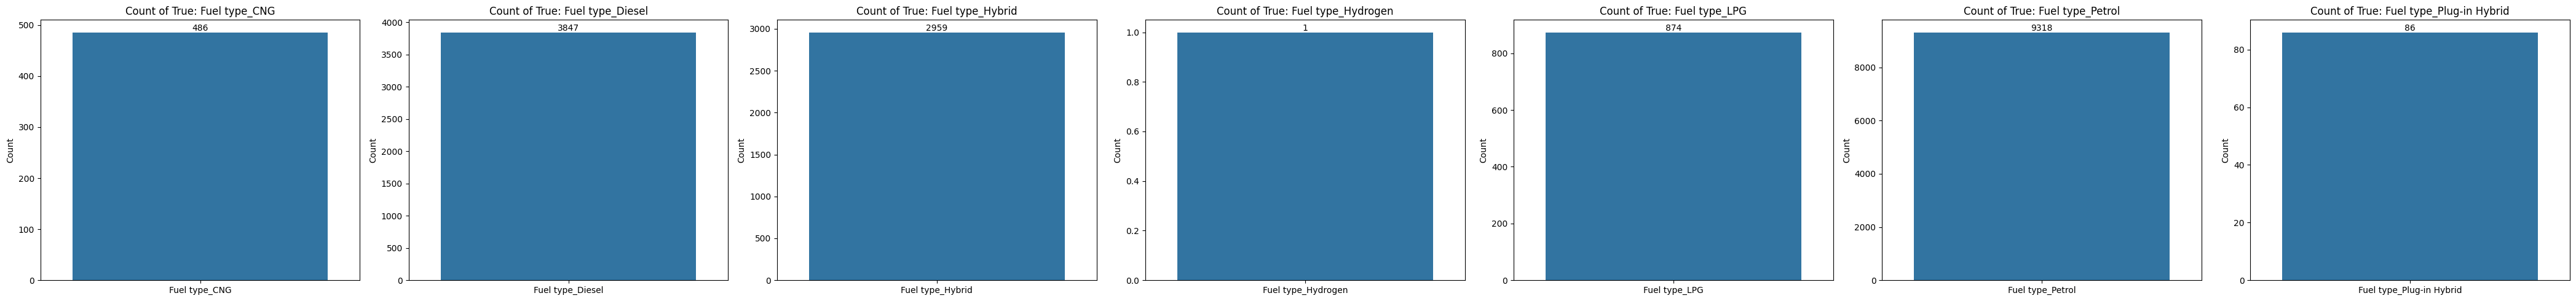

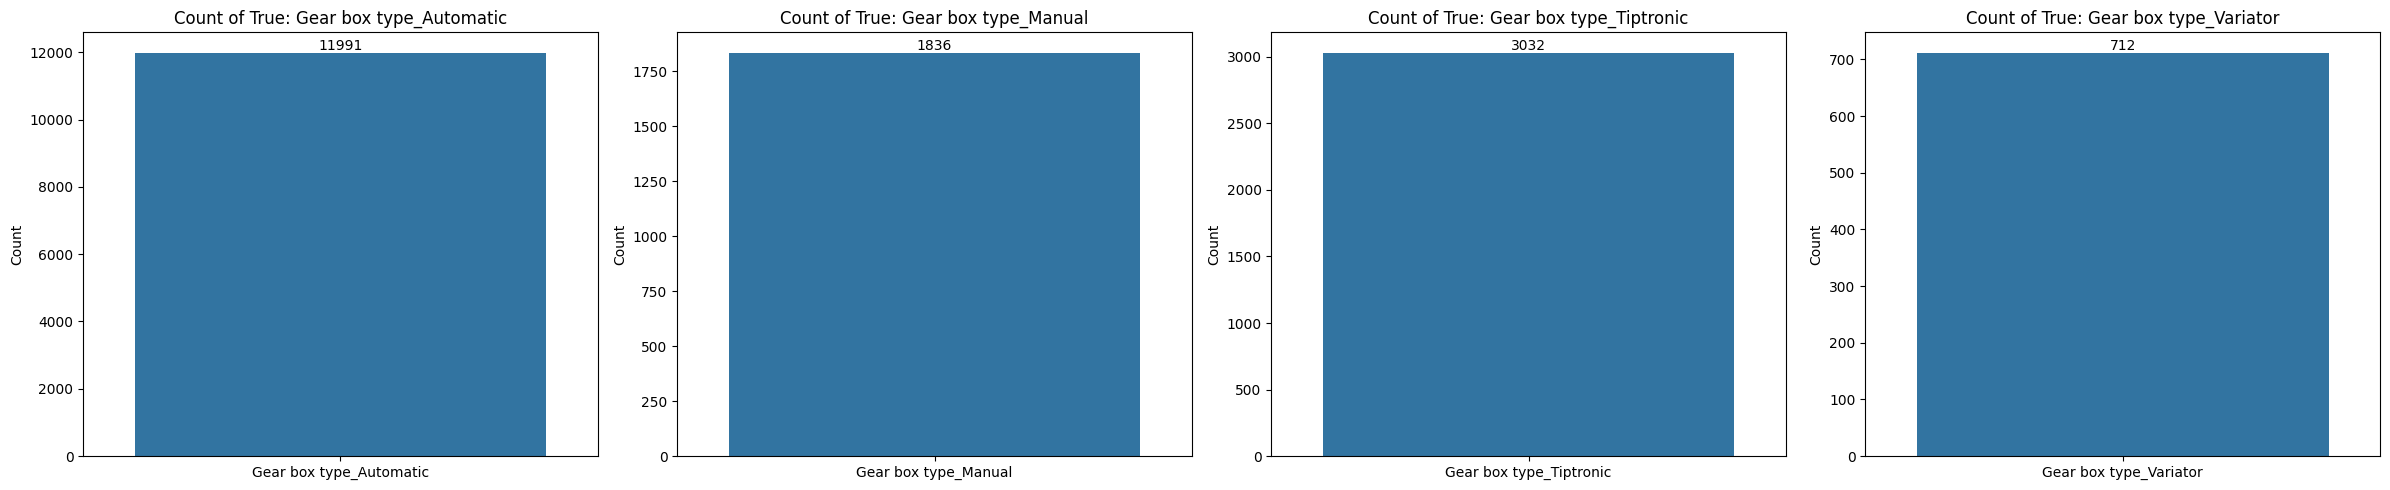

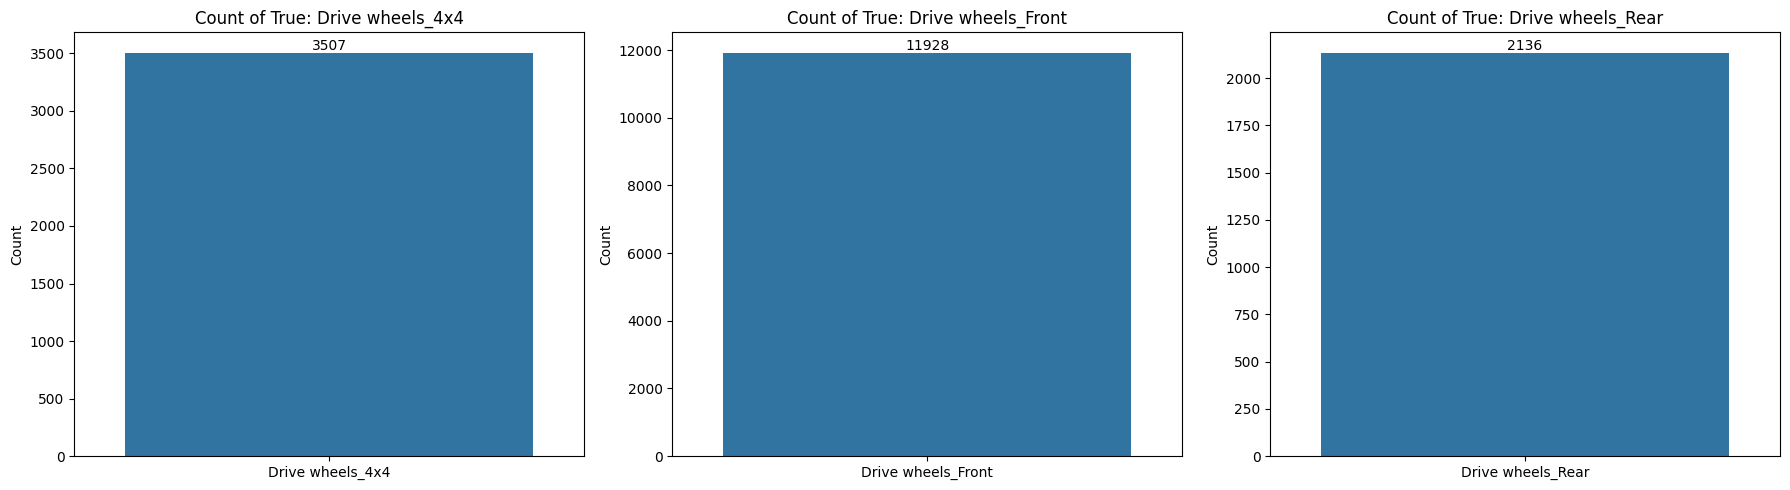

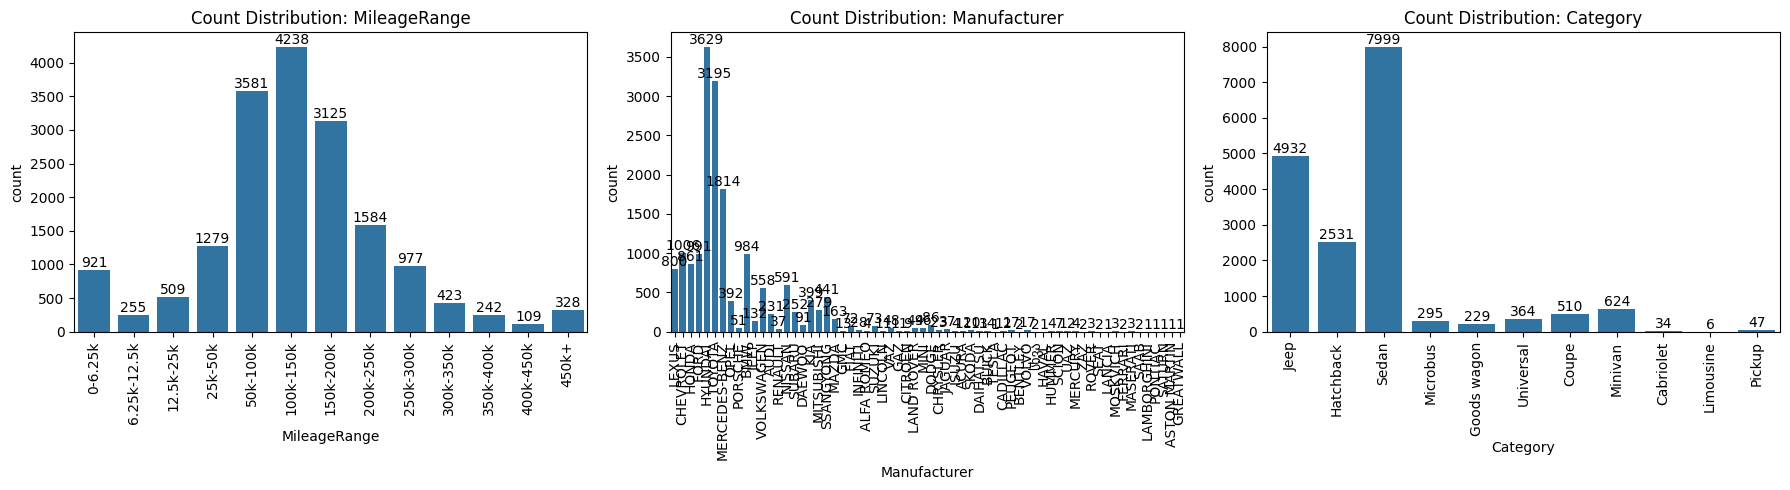

In [26]:
for col in dis_cols:
    plot_count_distributions(temp_df, col)

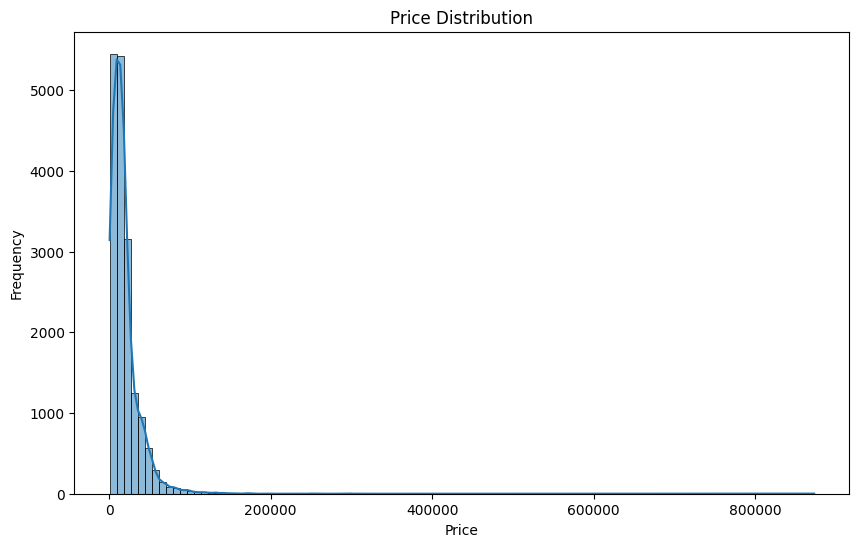

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=100, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

__Explanation:__

We have chosen to visualize the count distribution of the different aspects of the cars in the dataset. we gave done this to get a better understanding of which types of care are the most common in that dataset, so we get a better idea if this is high quality, luxious cars or is it more common and cheaper cars. 

We have observed that the primary category of cars in the data is `Sedab` (count: 7999), `Jeep` (count: 4932) and `Hatchback` (count: 2531), where the two domination `Manufacturers` are `Hyundai` (count: 3629), `Toyota` (count: 3195) and `Mercedes-Benz` (count: 1814), where the most common `Fuel type` is `Petrol` (count: 9318), `Diesel` (count: 3847) and `Hybrid` (count: 2959). 

The cars are mostly `Automatic` (count: 11991), `Tiptronic` (count: 3032), `Manual` (count: 1836) and `Variator` (count: 712) gear box types, where the most common `Drive wheels` are `Front` (count: 11928), `4x4` (count: 3507) and `Rear` (count: 2136).

Most of the cars are in the mileage range of `100k-150k` km (count: 4238), followed by `50k-100k` km (count: 3581) and `150k - 200k` km (count: 3125).

We can see that the price distribution is right skewed and most of the right prices are under 200k.

---

### 3.x Scatter plot

In [28]:
def plot_multiple_scatters(df, x_cols, y_col='Price', cols_per_row=3):
    total_plots = len(x_cols)
    rows = (total_plots + cols_per_row - 1) // cols_per_row 

    plt.figure(figsize=(cols_per_row * 5, rows * 4))

    for i, col in enumerate(x_cols, 1):
        plt.subplot(rows, cols_per_row, i)
        sns.scatterplot(data=df, x=col, y=y_col)
        plt.title(f'{col} vs {y_col}')
        plt.xlabel(col)
        plt.ylabel(y_col)

    plt.tight_layout()
    plt.show()

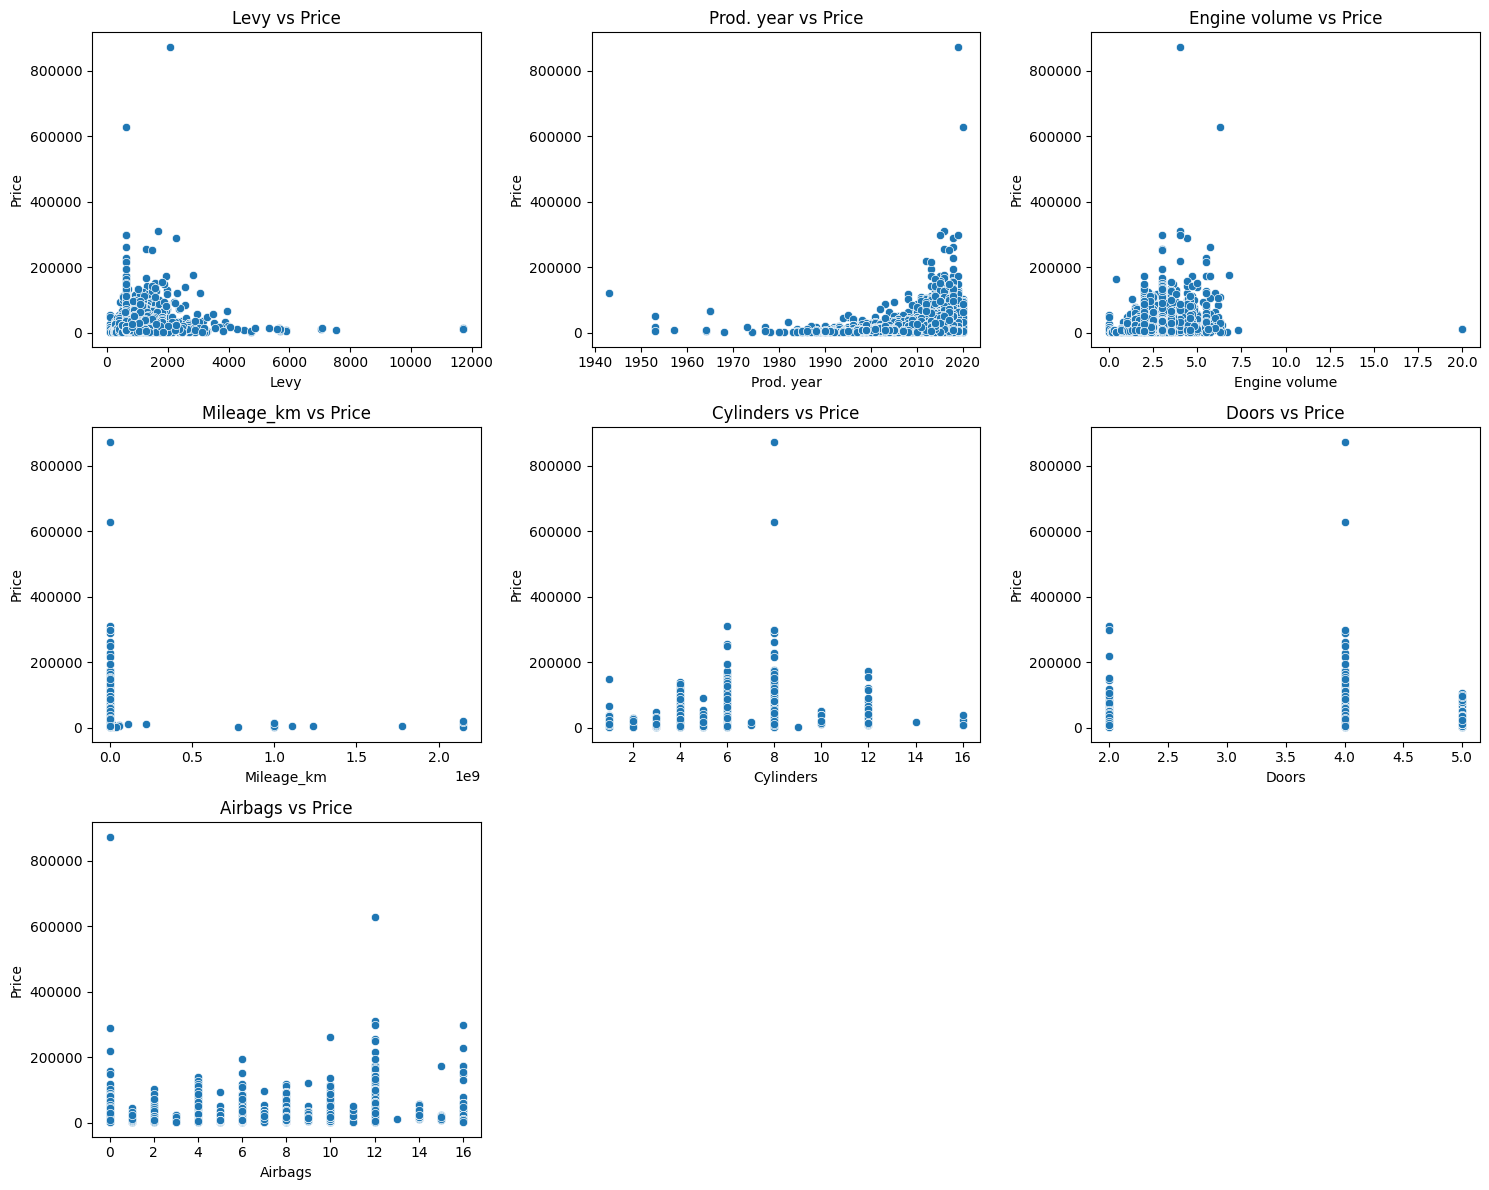

In [29]:
numeric_cols = ['Levy', 'Prod. year', 'Engine volume', 'Mileage_km', 'Cylinders', 'Doors', 'Airbags']

plot_multiple_scatters(df, numeric_cols)

__Explanation:__

We chose to visualize scatter plots between `Price` and several numerical features — including `Levy`, `Prod. year`, `Engine volume`, `Mileage_km`, `Cylinders`, `Doors`, and `Airbags` — to explore whether any individual variable has a direct, visible impact on car price.

From the scatter plots, we observed **no strong linear relationships** between these features and price. This is not unexpected. Features like `Cylinders`, `Doors`, and `Airbags` are discrete and tend to fall within a limited range (e.g., 4–8 cylinders), and their effect on price likely depends on **context** — for example, more airbags might be present in newer or luxury models, but not necessarily increase price in isolation.

Overall, these results suggest that **used car prices are influenced by a combination of features working together** (interactions), rather than a single feature driving the price. This is a key reason why more flexible models like Random Forest and Gradient Boosting often perform better than linear models in this domain.

#### 3.2 Correlation matrix

In [30]:
labes_to_encode = ['Manufacturer', 'Model', 'Category', 'Wheel', 'Color']

for label in labes_to_encode:
    le = LabelEncoder()
    df[label] = le.fit_transform(df[label])

df.iloc[0]

Price                        13328
Levy                          1399
Manufacturer                    32
Model                         1230
Prod. year                    2010
Category                         4
Leather interior                 1
Engine volume                 3.50
Mileage_km                  186005
Cylinders                     6.00
Doors                            4
Wheel                            0
Color                           12
Airbags                         12
turbo                            0
Fuel type_CNG                False
Fuel type_Diesel             False
Fuel type_Hybrid              True
Fuel type_Hydrogen           False
Fuel type_LPG                False
Fuel type_Petrol             False
Fuel type_Plug-in Hybrid     False
Drive wheels_4x4              True
Drive wheels_Front           False
Drive wheels_Rear            False
Gear box type_Automatic       True
Gear box type_Manual         False
Gear box type_Tiptronic      False
Gear box type_Variat

<Axes: >

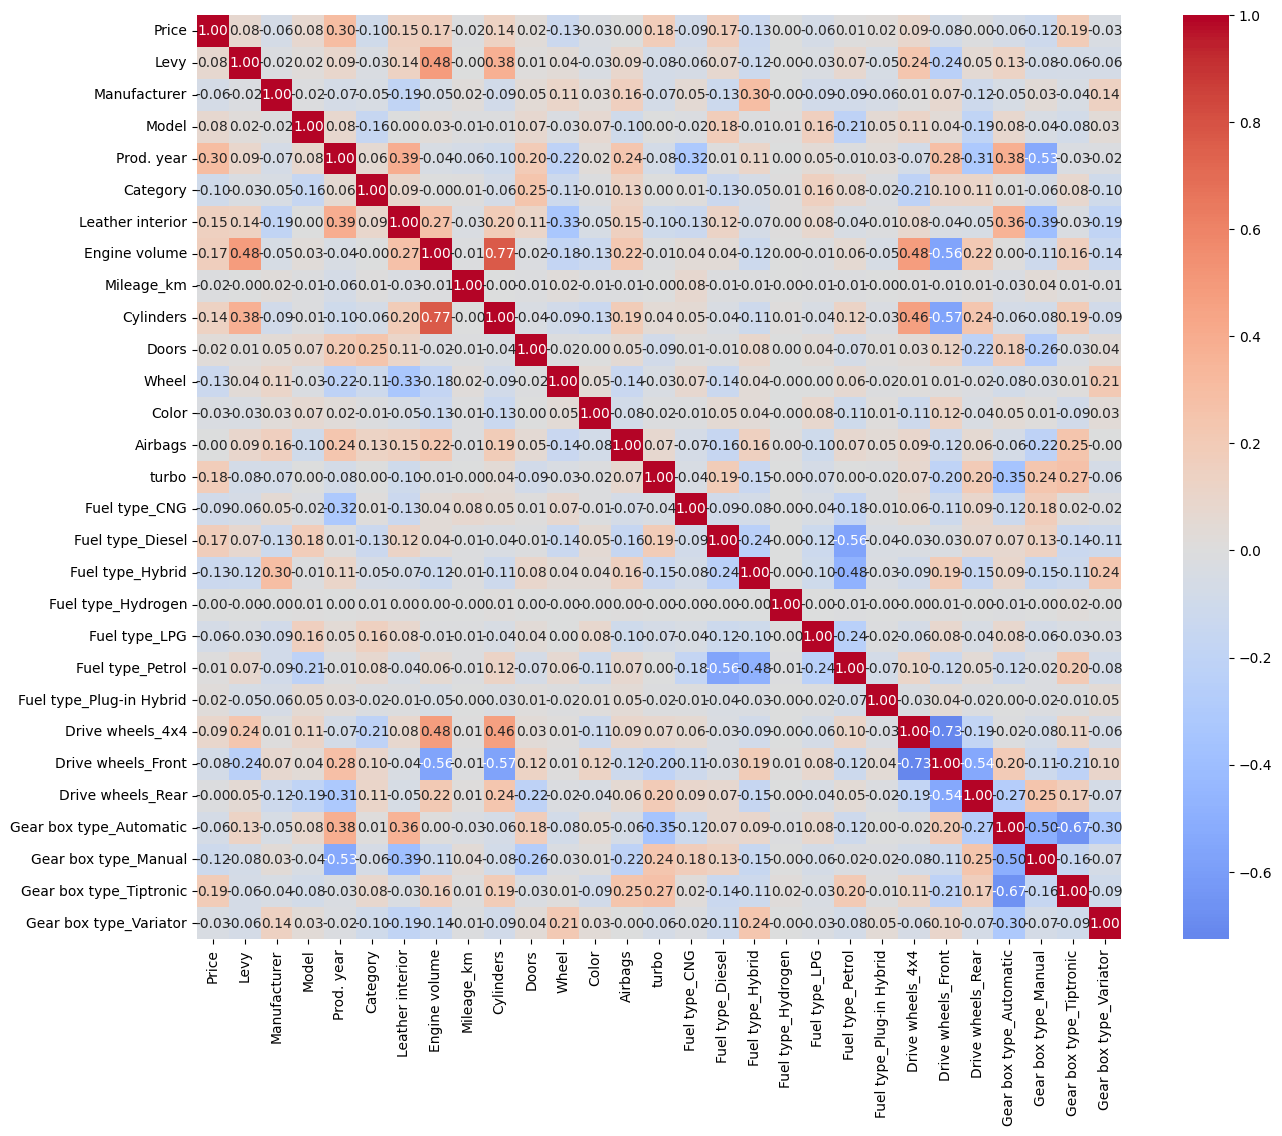

In [31]:
plt.figure(figsize=(16, 12))

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)

__Explanation:__

We first changed: `Manufacturer`, `Model`, `Category`, `Wheel`, and `Color` to have a numeric representation, by utilizing the `LabelEncoder`, so we get to see all columns correlation, and then they are also ready for the machine learning model later on.

For verifiying that the data has been changed, we use `df.iloc[0]` to get on record of the data, to see each column and its associated value.

For showing the correlation matrix, we use a combination of `seaborn` and `matplotlib` to create a heatmap, where we fisrt sets the figure size, and the use the `heatmap` function from `seaborn` to create the heatmap, with the parameters:

- `df.corr()`: the correlation matrix of the dataframe.
- `annot=True`: shows the correlation value for each individual cell.
- `fmt=".2f"`: the decimal format of the correlation value (0.00).
- `cmap='coolwarm'`: the color map used for the heatmap.
- `center=0`:  centers the color of the heatmap.
- `square=True`: makes the cells square, so they are not rectangular. 


When we look at our correlation matrix, we can observe that overall ther are not many strong correlations present in the data and alot is close to 0, which indicates that there are no correlation at all. The correlation between `Levy` and `Price` is 0.08, which means nearly no correlation at all. We would have believed that correlation between `Levy` and `Price` should be higher, but it is not, due to taxing normally follows the price of the car; however maybe this is not the case of where the data is from. Additionally the `Milage_km` correlation with `Price` is -0.02, which comes as shock, because its like saying a car with 100.000 km on it is the same as a car with 10.000 km on it, which is not ture.

The correlation between `Prod. year` and `Price` is 0.30, which is a bit higher, then it was with `Levy`, but still not that high. Again we would probably have expected this to be higher, but makes sense, its possitive, which means the newer the car is, the more expensive it is.

---

## 4. Model Selection and training:

This section will include:
- Model selection
- Data splitting
- Model training & Validation
- Model evaluation

### 4.1 The selected model(s)

__We have selected the following models for this project__:
- Multiple Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressors

__The reason for the selected models is as follows__:
- __Multiple Linear Regression__:
    
    MLR was chosen as a simple baseline model. It helps us understand how the features relate to the target in a linear framework. While our scatter plots and early exploration showed that the relationships between features and price are not strictly linear, MLR still serves as a useful comparison point to measure the performance gain from more complex models. It is also computationally efficient and interpretable.

    As we saw in the correlation matrix and scatter plots, this MLR is not ideal for this data, because its non linear relationship between the features and the target variable (price). However have chosen to include it, as a baseline for understanding the effect of the tree based models sorounding this task.


- __Random Forest Regressor__: 

    Random Forest is an ensemble model that uses multiple decision trees and averages their predictions. It is capable of modeling non-linear relationships, handles both numerical and categorical data well, and is less sensitive to outliers and multicollinearity. It also provides feature importance scores, which help us understand which variables contribute the most to the predictions.


- __Gradient Boosting Regressors (XGBoost)__: 
    
    Gradient Boosting is a powerful boosting technique that builds trees sequentially, focusing on correcting the errors of previous trees. It typically achieves very high accuracy, especially on structured/tabular data like ours. We chose XGBoost for its performance, regularization capabilities, and support for fine-grained control over model behavior.


__We are going to be using the following error metrics to evalaute the models__:
- __R²__: 
    
    Indicates how much of the variance in the target variable is explained by the model. A higher R² means the model fits the data better. It gives a good general sense of model performance.

- __mean absolute error (MAE)__: 

    Represents the average absolute difference between predicted and actual prices. It is easy to interpret and not heavily influenced by outliers.

- __mean squared error (MSE)__:  
    
    Similar to MAE, but squares the errors, so larger errors are penalized more heavily. This is useful if large errors are more problematic in the use case.

- __root mean squared error (RMSE)__: 

    The square root of MSE, which brings the error back to the original units (price). It combines the benefits of MSE (penalizing large errors) with easier interpretability.

This is a regression problem and twe are trying to predict a continous value (price), and not a categorical value (yes/no, 1/0, etc.), then we should have use the following metrics:
- accuracy score
- precision score
- recall score
- f1 score

Additionaly we are going to be using the grid search approach for find the best suited hyperparameters for each individual model. This process is done by using the `GridSearchCV` function from `sklearn`. This makes the process of finding the right hyperparameters more streamlined, because we don't have to do it manually, and we can also use cross-validation to get a better estimate of the model performance.

---

### 4.2 Data splitting into sets


In [32]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Price']), df['Price'], test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [33]:
print(f"Train set shape: {X_train.shape[0]}, percentage: {X_train.shape[0] / df.shape[0] * 100:.2f}%")
print(f"Validation set shape: {X_val.shape[0]}, percentage: {X_val.shape[0] / df.shape[0] * 100:.2f}%")
print(f"Test set shape: {X_test.shape[0]}, percentage: {X_test.shape[0] / df.shape[0] * 100:.2f}%")

Train set shape: 10542, percentage: 60.00%
Validation set shape: 3514, percentage: 20.00%
Test set shape: 3515, percentage: 20.00%


__Explanation:__

The dataset has been split into 3 sets: training, validation and test set.

The `test_size` is 0.2 (20%) for the first `train_test_split` and 0.25 (25%) for the secound `train_test_split`, these sizes in procentage is different because we want a overall split of 60% training, 20% validation and 20% test set. And when you start with 80% training and 20% test, in the first `train_test_split`, and then split the training set into 75% training and 25% validation, you end up with 60% training, 20% validation and 20% test set.

The `random_state` is set to 42, so that the results are is the same every time we run the code, so we can reproduce the results.

---

### 4.3 Model training and validation

This section will include:

- Helping functions
- x
- y
- z

*Helping methods for training, validation and testing the models*:

In [34]:
def display_grid_search_results(grid):
    results = grid.cv_results_
    
    print("GridSearchCV validation results:")
    print("Best parameters:", grid.best_params_)
    print("")

    for metric in ['r2', 'neg_mae', 'neg_mse', 'neg_rmse']:
        mean_score = results[f'mean_test_{metric}']
        print(f"{metric}:", mean_score[grid.best_index_])

In [35]:
scoring = {
    'r2': 'r2',
    'neg_mae': 'neg_mean_absolute_error',
    'neg_mse': 'neg_mean_squared_error',
    'neg_rmse': 'neg_root_mean_squared_error',
}

In [36]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = root_mean_squared_error(y, y_pred)
    
    return r2, mse, mae, rmse

---

#### 4.3.1 Model 1: Multiple Linear Regression

In [37]:
mlr_param_grid = {}

mlr_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=mlr_param_grid,
    scoring=scoring,
    cv=5,
    refit='neg_rmse',
    n_jobs=-1,
)

mlr_grid.fit(X_train, y_train)

display_grid_search_results(mlr_grid)

mlr_best_model = mlr_grid.best_estimator_

GridSearchCV validation results:
Best parameters: {}

r2: 0.26972992885615066
neg_mae: -9993.959500175322
neg_mse: -298480490.30240357
neg_rmse: -16918.87716686192


In [38]:
val_r2, val_mse, val_mae, val_rmse = evaluate_model(mlr_best_model, X_val, y_val)

print(f"Validation R2: {val_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Validation R2: 0.2308
Validation MSE: 246833293.5631
Validation MAE: 10257.6670
Validation RMSE: 15710.9291


In [39]:
with open(f'./models/mlr_best_model.pkl', 'wb') as f:
    pickle.dump(mlr_best_model, f)

---

#### 4.3.2 Model 2: Random Forest Regressor

In [40]:
rfr_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rfr_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rfr_param_grid,
    scoring=scoring,
    cv=5,
    refit='neg_rmse',
    n_jobs=-1,
)

rfr_grid.fit(X_train, y_train)

display_grid_search_results(rfr_grid)

rfr_best_model = rfr_grid.best_estimator_

GridSearchCV validation results:
Best parameters: {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

r2: 0.6661740070288353
neg_mae: -4693.006226646547
neg_mse: -150558650.19867054
neg_rmse: -11532.814206380051


In [41]:
val_r2, val_mse, val_mae, val_rmse = evaluate_model(rfr_best_model, X_val, y_val)

print(f"Validation R2: {val_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Validation R2: 0.7631
Validation MSE: 76005152.1178
Validation MAE: 4482.6363
Validation RMSE: 8718.0934


In [42]:
with open(f'./models/rfr_best_model.pkl', 'wb') as f:
    pickle.dump(rfr_best_model, f)

---

#### 4.3.3 Model 3: Gradient Boosting Regressors

In [43]:
gbr_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1],
}

gbr_grid = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=gbr_param_grid,
    scoring=scoring,
    cv=5,
    refit='neg_rmse',
    n_jobs=-1,
)

gbr_grid.fit(X_train, y_train)

display_grid_search_results(gbr_grid)

gbr_best_model = gbr_grid.best_estimator_

GridSearchCV validation results:
Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1}

r2: 0.6593478798866272
neg_mae: -4787.8849609375
neg_mse: -151994248.8
neg_rmse: -11637.235546875


In [44]:
val_r2, val_mse, val_mae, val_rmse = evaluate_model(gbr_best_model, X_val, y_val)

print(f"Validation R2: {val_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Validation R2: 0.7669
Validation MSE: 74794616.0000
Validation MAE: 4626.9312
Validation RMSE: 8648.3877


In [45]:
with open(f'./models/gbr_best_model.pkl', 'wb') as f:
    pickle.dump(gbr_best_model, f)

---

__Explanation:__

__Hyperparameters for grid search:__

As we stated above, we are utilizing the grid search approach for hyperparameter tuning. We are doing this for finding the hyperparameters the gives the best results for each model. We are using the `GridSearchCV` from `sklearn` to do this. We are using the following hyperparameters for each model:

- The 1st parmeter is always the model we want to use, in this case `MultipleLinearRegression`, `RandomForestRegressor` or `GradientBoostingRegressor`.

- The 2nd parameter is `param_grid`, is a dict containing the hyperparameters we want to tune.

- The 3rd parameter is the `scoring` parameter, which is set to our dict `scoring`, which contains all the error metrics we utilize for evaluating the models.

- The 4th parameter is `cv`, which is number of how many folds we are using for cross validation, we are using 5 folds.

- The 5th parameter is `refit`- due to having this `scoring` dict, we still have to tell grid search which metric is the main one it should utilize for the its own evaluation. 
We have chosen to use `neg_rmse` as the main metric due to [reason]...

- The 6th parameter `n_jobs`, tells grid search the amount of CPU cores can be used for parallel processing. We have given it -1, so it have access to all the CPU cores available. 

__Hyperparameters adjustments for models:__

- __Multiple Linear Regression__:
    -  There are not any performances or accuracy hyperparameters for this model, but we can still run it through the grid search for the sake of cross validation. Important to note is that the model `LinearRegression` does have some parameters, but they are more related to behavioral and computational aspects of the model. 

- __Random Forest Regressor__:
    - `random_state`:
    - `n_estimators`: 
    - `max_depth`:
    - `min_samples_split`:
    - `min_samples_leaf`:


- __Gradient Boosting Regressors__:
    - `n_estimators`: 
    - `max_depth`: 
    - `learning_rate`: 
    - `subsample`: 


__Tackling overfitting:__

text

---

### 4.4 Model evaluation

This section will include:

- x
- y
- z

#### 4.4.1 Model 1: Multiple Linear Regression

In [46]:
r2, mse, mae, rmse = evaluate_model(mlr_best_model, X_test, y_test)

print("MLR Evaluation on Test Set:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MLR Evaluation on Test Set:
R2: 0.2522
MSE: 354987625.3321
MAE: 10590.5538
RMSE: 18841.1153


---

#### 4.4.2 Model 2: Random Forest Regressor

In [47]:
r2, mse, mae, rmse = evaluate_model(rfr_best_model, X_test, y_test)

print("RFR Evaluation on Test Set:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

RFR Evaluation on Test Set:
R2: 0.7418
MSE: 122587767.9745
MAE: 4551.6982
RMSE: 11071.9361


---

#### 4.4.3 Model 3: Gradient Boosting Regressors

In [48]:
r2, mse, mae, rmse = evaluate_model(gbr_best_model, X_test, y_test)

print("GBR Evaluation on Test Set:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

GBR Evaluation on Test Set:
R2: 0.7419
MSE: 122508992.0000
MAE: 4826.4292
RMSE: 11068.3779


---

#### 4.4.4 Comparison of Models

To compare the performance of the three regression models: Multiple Linear Regression (MLR), Random Forest Regressor (RFR), and Gradient Boosting Regressor (GBR) - we evaluated them on a held-out test set using four standard regression metrics:

| Model | R² (↑) | MAE (↓) | MSE (↓) | RMSE (↓) |
|-------|--------|----------|-------------|-------------|
| MLR   | 0.2522 | 10,590.55 | 354,987,625.33 | 18,841.12 |
| RFR   | 0.7418 | 4,551.70  | 122,587,767.97 | 11,071.94 |
| GBR   | **0.7419** | 4,826.43  | **122,508,992.00** | **11,068.38** |

- **R² Score**: Both RFR and GBR achieved significantly higher R² values (~0.74) compared to MLR (0.25), indicating that tree-based models explained a much larger portion of the variance in car prices.

- **MAE / RMSE**: MLR had the highest errors, with an average deviation of over 10,000. Both RFR and GBR cut the error by more than 50%, with GBR performing *slightly* better in RMSE and MSE, though RFR had a lower MAE.

- **Model Preference**: While both tree-based models performed similarly, **GBR achieved the lowest RMSE and MSE**, making it the best-performing model on this dataset by a narrow margin. RFR, however, had a slightly lower MAE, suggesting it might make fewer large prediction errors on average.

In contrast, **Multiple Linear Regression underperformed**, likely due to its inability to capture complex non-linear interactions present in the data.

---

**Conclusion**: Tree-based ensemble models, particularly Gradient Boosting Regressor, are better suited for used car price prediction tasks, as they handle non-linear relationships and mixed feature types more effectively than linear models.
